# TAREA #1: ENTENDER EL ENUNCIADO DEL PROBLEMA Y EL CASO PRÁCTICO


<table>
  <tr><td>
    <img src="https://drive.google.com/uc?id=1yJKgmHrRFnBk987HJfeDrMcTEXtk0z7W"
         alt="Fashion MNIST sprite"  width="1000">
  </td></tr>
  <tr><td align="center">
    <b>Figura 1. Predicción de la Retención de Empleados
  </td></tr>
</table>


![alt text](https://drive.google.com/uc?id=1u38Inu9eSZM02MlhLIzxY7aguGnzh17v)

![alt text](https://drive.google.com/uc?id=1UrsB2DV303p3F5-P96jZLKF_ZtLPIHg4)


![alt text](https://drive.google.com/uc?id=1DooMDDmd0ilm18AKFPfHar3SU0onyWwe)

# TAREA #2: IMPORTAR LAS LIBRERÍAS Y LOS DATASETS

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente.')
print(f'TensorFlow version: {tf.__version__}')

Librerías importadas correctamente.
TensorFlow version: 2.21.0


In [3]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Usin

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [5]:
import os

ruta = r'C:/Users/KAREN/OneDrive/Desktop/pract2/Human_Resources.csv'

# ¿Existe la carpeta?
print("¿Carpeta existe?", os.path.exists(r'C:/Users/KAREN/OneDrive/Desktop/pract2'))

# ¿Qué archivos hay en esa carpeta?
carpeta = r'C:/Users/KAREN/OneDrive/Desktop/pract2'
if os.path.exists(carpeta):
    print("Archivos encontrados:")
    for f in os.listdir(carpeta):
        print(" -", f)
else:
    print("La carpeta NO existe")

¿Carpeta existe? True
Archivos encontrados:
 - Esqueleto_Departamento_de_Recursos_Humanos.ipynb
 - Human_Resources.csv


In [7]:
# Cargar el dataset desde archivo CSV local
df = pd.read_csv(r'C:/Users/KAREN/OneDrive/Desktop/pract2/Human_Resources.csv')
print('Dataset cargado correctamente.')
print(f'Forma del dataset: {df.shape}')

Dataset cargado correctamente.
Forma del dataset: (1470, 35)


In [8]:
# Vista general del dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# Tipos de datos de cada columna
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
# Estadísticas descriptivas del dataset
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
# Información general: tipos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
# 35 características en total, cada una con 1470 puntos de datos
print(f'Número de columnas: {df.shape[1]}')
print(f'Número de filas: {df.shape[0]}')

Número de columnas: 35
Número de filas: 1470


In [13]:
# Listado de todas las columnas
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# TAREA #3: VISUALIZACIÓN DEL DATASET

In [14]:
# Reemplazamos las columnas 'Attritition' y 'overtime' por enteros antes de poder llevar a cabo cualquier visualización

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime']  = df['OverTime'].map({'Yes': 1, 'No': 0})

print('Conversión completada:')
print(df[['Attrition', 'OverTime']].value_counts())

Conversión completada:
Attrition  OverTime
0          0           944
           1           289
1          1           127
           0           110
Name: count, dtype: int64


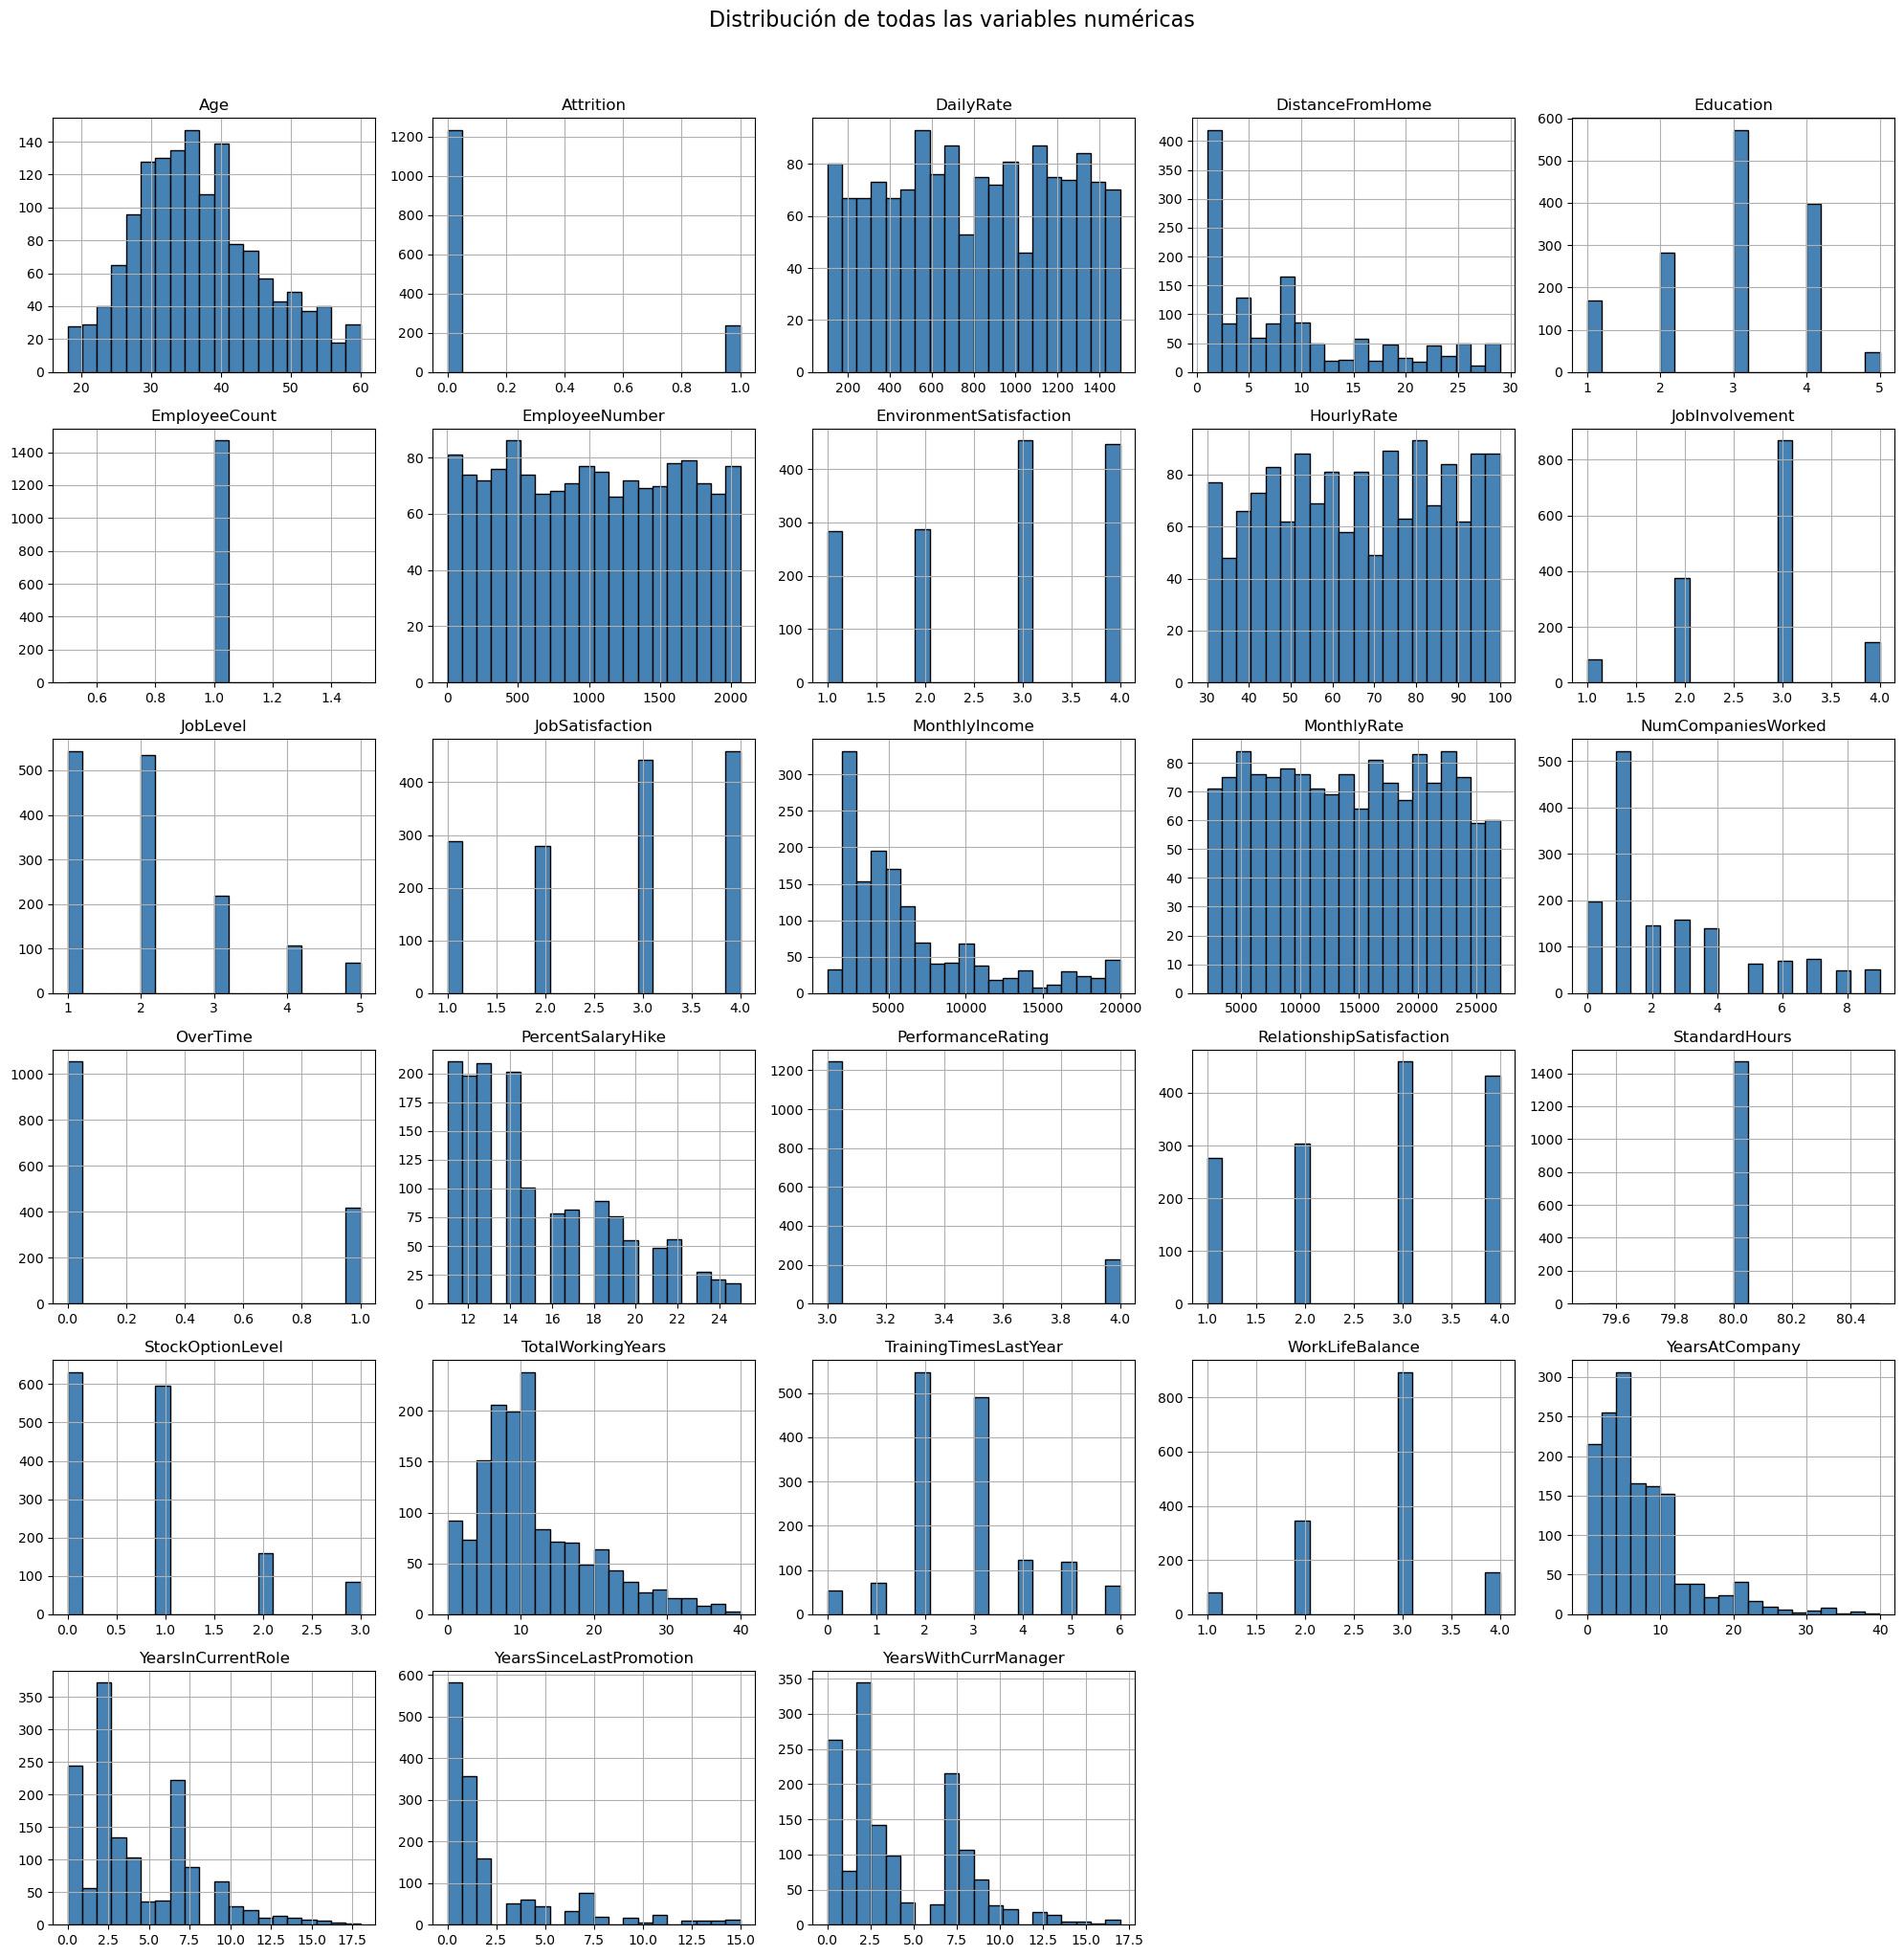

In [15]:
# Histograma de todas las variables numéricas
df.hist(figsize=(20, 20), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribución de todas las variables numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Veamos si nos faltan datos, ¡afortunadamente no es así!
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

Valores nulos por columna:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

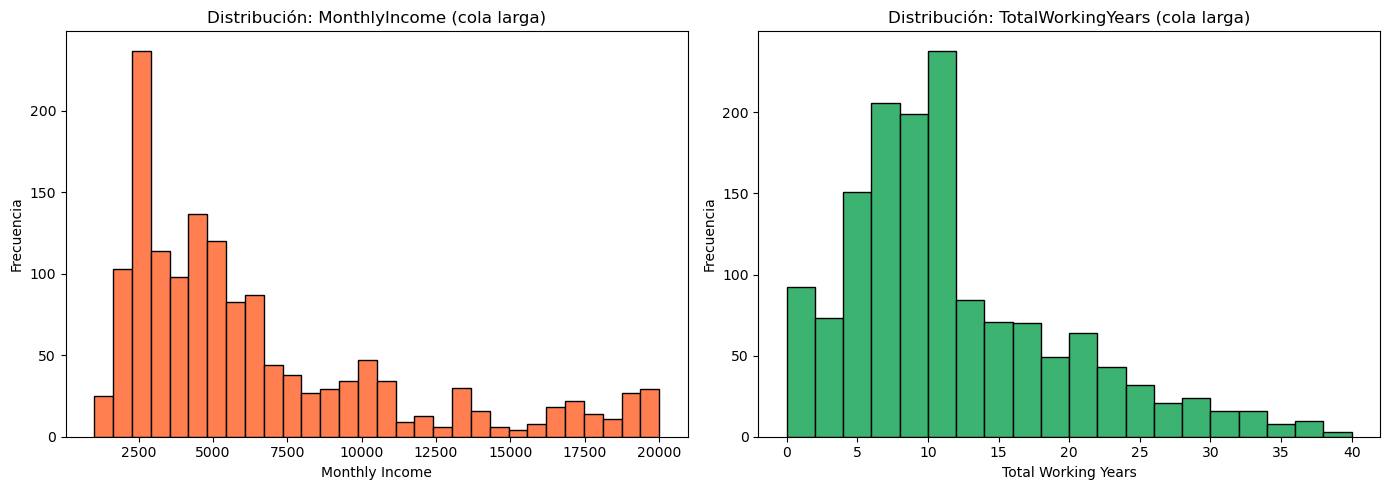

In [17]:
# Algunas características como 'MonthlyIncome' y 'TotalWorkingYears' tienen una distribución con una cola muy larga (long tail distribution)
# Tiene sentido que nos desagamos de 'EmployeeCount' y 'Standardhours' ya que estos campos no cambian de un empleado a otro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MonthlyIncome'], bins=30, color='coral', edgecolor='black')
axes[0].set_title('Distribución: MonthlyIncome (cola larga)')
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['TotalWorkingYears'], bins=20, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribución: TotalWorkingYears (cola larga)')
axes[1].set_xlabel('Total Working Years')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [18]:
# Tiene sentido deshacerse de 'EmployeeCount' , 'Standardhours' y 'Over18' ya que son campos que no cambian de un empleado a otro
# Eliminemos 'EmployeeNumber' también
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
print(f'Columnas eliminadas. Nueva forma del dataset: {df.shape}')

Columnas eliminadas. Nueva forma del dataset: (1470, 31)


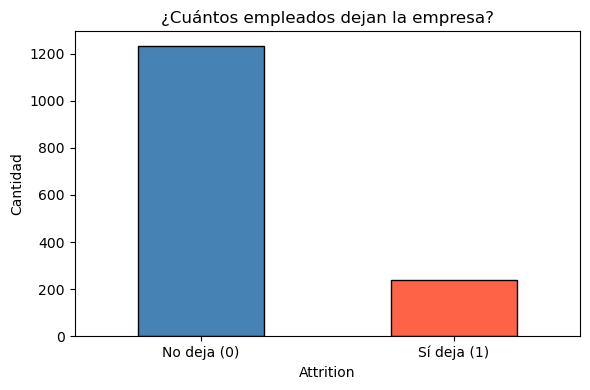

In [19]:
# Veamos cuantos empleados dejan la empresa!
plt.figure(figsize=(6, 4))
ax = df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['No deja (0)', 'Sí deja (1)'], rotation=0)
plt.title('¿Cuántos empleados dejan la empresa?')
plt.xlabel('Attrition')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [21]:
# Contamos el número de empleados que se quedaron y que se fueron
# Parece que estamos ante un conjunto de datos desequilibrado
left_df   = df[df['Attrition'] == 1]
stayed_df = df[df['Attrition'] == 0]

print(f'Empleados que se fueron:   {len(left_df)} ({len(left_df)/len(df)*100:.1f}%)')
print(f'Empleados que se quedaron: {len(stayed_df)} ({len(stayed_df)/len(df)*100:.1f}%)')
print('\n Dataset DESEQUILIBRADO: hay muchos más empleados que se quedan que los que se van.')

Empleados que se fueron:   237 (16.1%)
Empleados que se quedaron: 1233 (83.9%)

 Dataset DESEQUILIBRADO: hay muchos más empleados que se quedan que los que se van.


In [22]:
# Estadísticas descriptivas de los que SE FUERON
left_df.describe()

# Comparemos la media y el error estándar de los empleados que se quedaron y se fueron
# 'age': la edad media de los empleados que se quedaron es mayor en comparación con los que se fueron
# 'DailyRate': El rate diario de los empleados que se quedaron es mayor
# 'DistanceFromHome': Los empleados que se quedan viven más cerca del trabajo
# 'EnvironmentSatisfaction' & 'JobSatisfaction': Los empleados que se quedan están en general más satisfechos con sus trabajos
# 'StockOptionLevel': Los empleados que se quedan tienen un mayor nivel de stocks options

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,237.000000,237.0,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,...,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
mean,33.607595,1.0,750.362869,10.632911,2.839662,2.464135,65.573840,2.518987,1.637131,2.468354,...,3.156118,2.599156,0.527426,8.244726,2.624473,2.658228,5.130802,2.902954,1.945148,2.852321
std,9.689350,0.0,401.899519,8.452525,1.008244,1.169791,20.099958,0.773405,0.940594,1.118058,...,0.363735,1.125437,0.856361,7.169204,1.254784,0.816453,5.949984,3.174827,3.153077,3.143349
min,18.000000,1.0,103.000000,1.000000,1.000000,1.000000,31.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.0,408.000000,3.000000,2.000000,1.000000,50.000000,2.000000,1.000000,1.000000,...,3.000000,2.000000,0.000000,3.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
50%,32.000000,1.0,699.000000,9.000000,3.000000,3.000000,66.000000,3.000000,1.000000,3.000000,...,3.000000,3.000000,0.000000,7.000000,2.000000,3.000000,3.000000,2.000000,1.000000,2.000000
75%,39.000000,1.0,1092.000000,17.000000,4.000000,4.000000,84.000000,3.000000,2.000000,3.000000,...,3.000000,4.000000,1.000000,10.000000,3.000000,3.000000,7.000000,4.000000,2.000000,5.000000
max,58.000000,1.0,1496.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,15.000000,15.000000,14.000000


In [23]:
# Estadísticas descriptivas de los que SE QUEDARON
stayed_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1233.000000,1233.0,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,...,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000
mean,37.561233,0.0,812.504461,8.915653,2.927007,2.771290,65.952149,2.770479,2.145985,2.778589,...,3.153285,2.733982,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
std,8.888360,0.0,403.208379,8.012633,1.027002,1.071132,20.380754,0.692050,1.117933,1.093277,...,0.360408,1.071603,0.841985,7.760719,1.293585,0.681907,6.096298,3.649402,3.234762,3.594116
min,18.000000,0.0,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.0,477.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.0,817.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,43.000000,0.0,1176.000000,13.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,16.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,0.0,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,38.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


In [24]:
# Comparación de medias: empleados que se fueron vs. que se quedaron
comparison = pd.DataFrame({
    'Se fueron (media)':   left_df.mean(numeric_only=True),
    'Se quedaron (media)': stayed_df.mean(numeric_only=True)
})
comparison

,Se fueron (media),Se quedaron (media)
Age,33.607595,37.561233
Attrition,1.000000,0.000000
DailyRate,750.362869,812.504461
DistanceFromHome,10.632911,8.915653
Education,2.839662,2.927007
EnvironmentSatisfaction,2.464135,2.771290
HourlyRate,65.573840,65.952149
JobInvolvement,2.518987,2.770479
JobLevel,1.637131,2.145985
JobSatisfaction,2.468354,2.778589


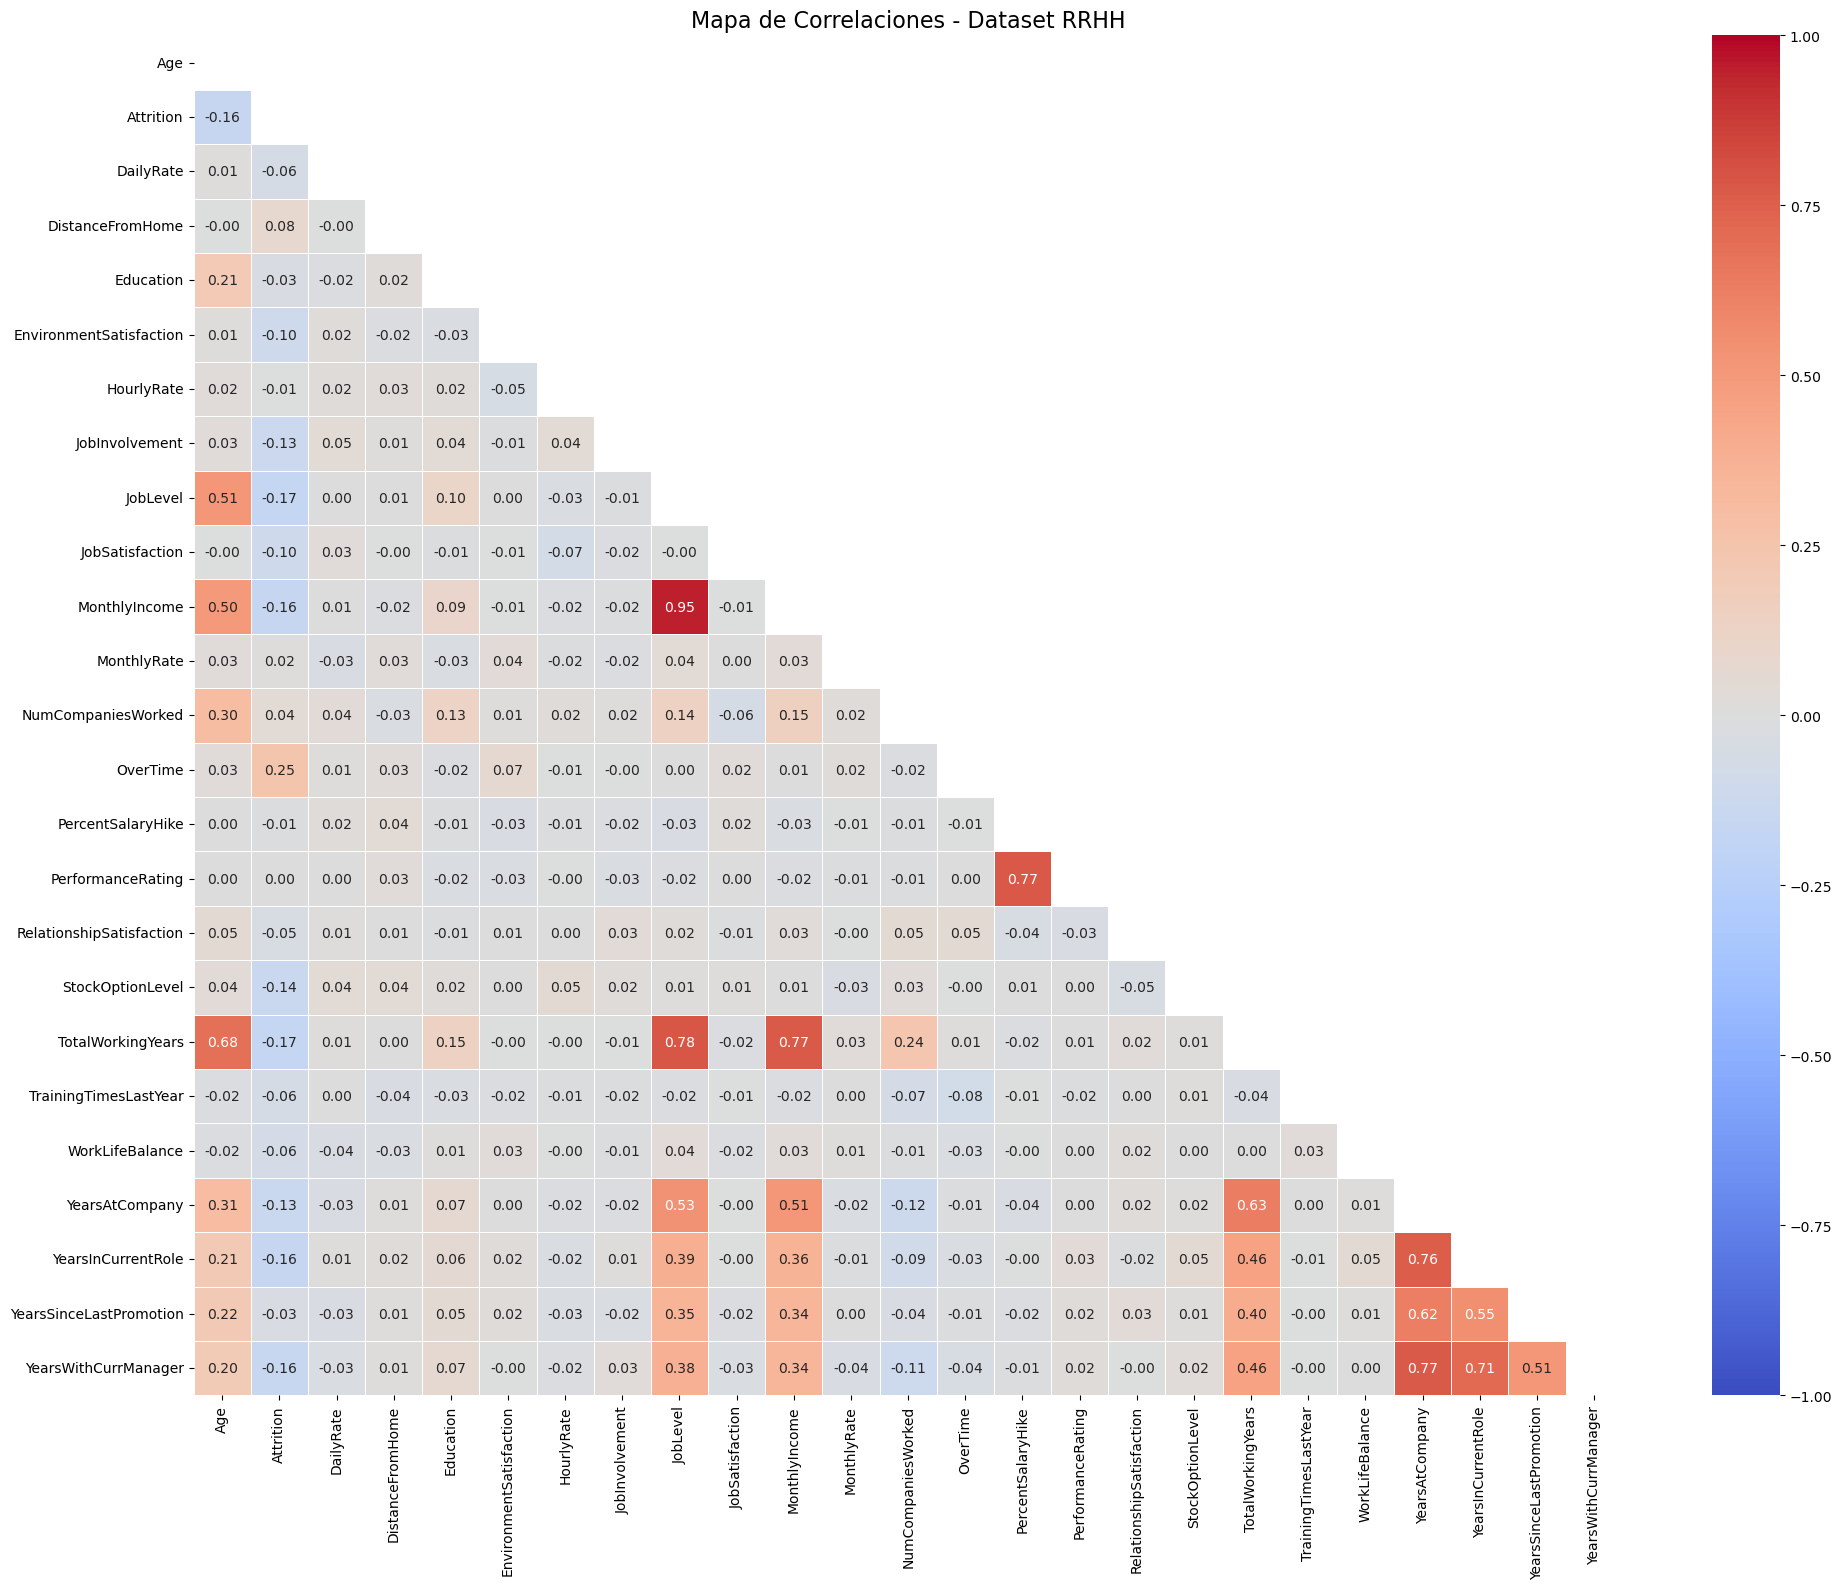

In [25]:

# Job level está altamente correlacionado con el número total de horas de trabajo
# Monthly income está altamente correlacionado con Job level
# Monthly income está altamente correlacionado con el número total de horas de trabajo
# Age está altamente correlacionado con los ingresos mensuales

# Mapa de correlaciones
plt.figure(figsize=(20, 16))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Correlaciones - Dataset RRHH', fontsize=16)
plt.tight_layout()
plt.show()


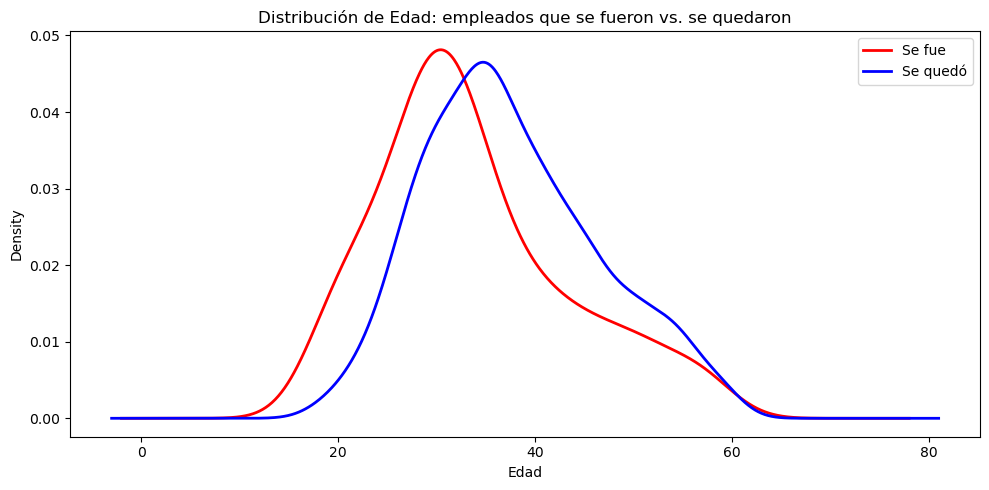

In [26]:
# KDE plots: Age vs Attrition
plt.figure(figsize=(10, 5))
left_df['Age'].plot.kde(label='Se fue', color='red', linewidth=2)
stayed_df['Age'].plot.kde(label='Se quedó', color='blue', linewidth=2)
plt.title('Distribución de Edad: empleados que se fueron vs. se quedaron')
plt.xlabel('Edad')
plt.legend()
plt.tight_layout()
plt.show()

ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

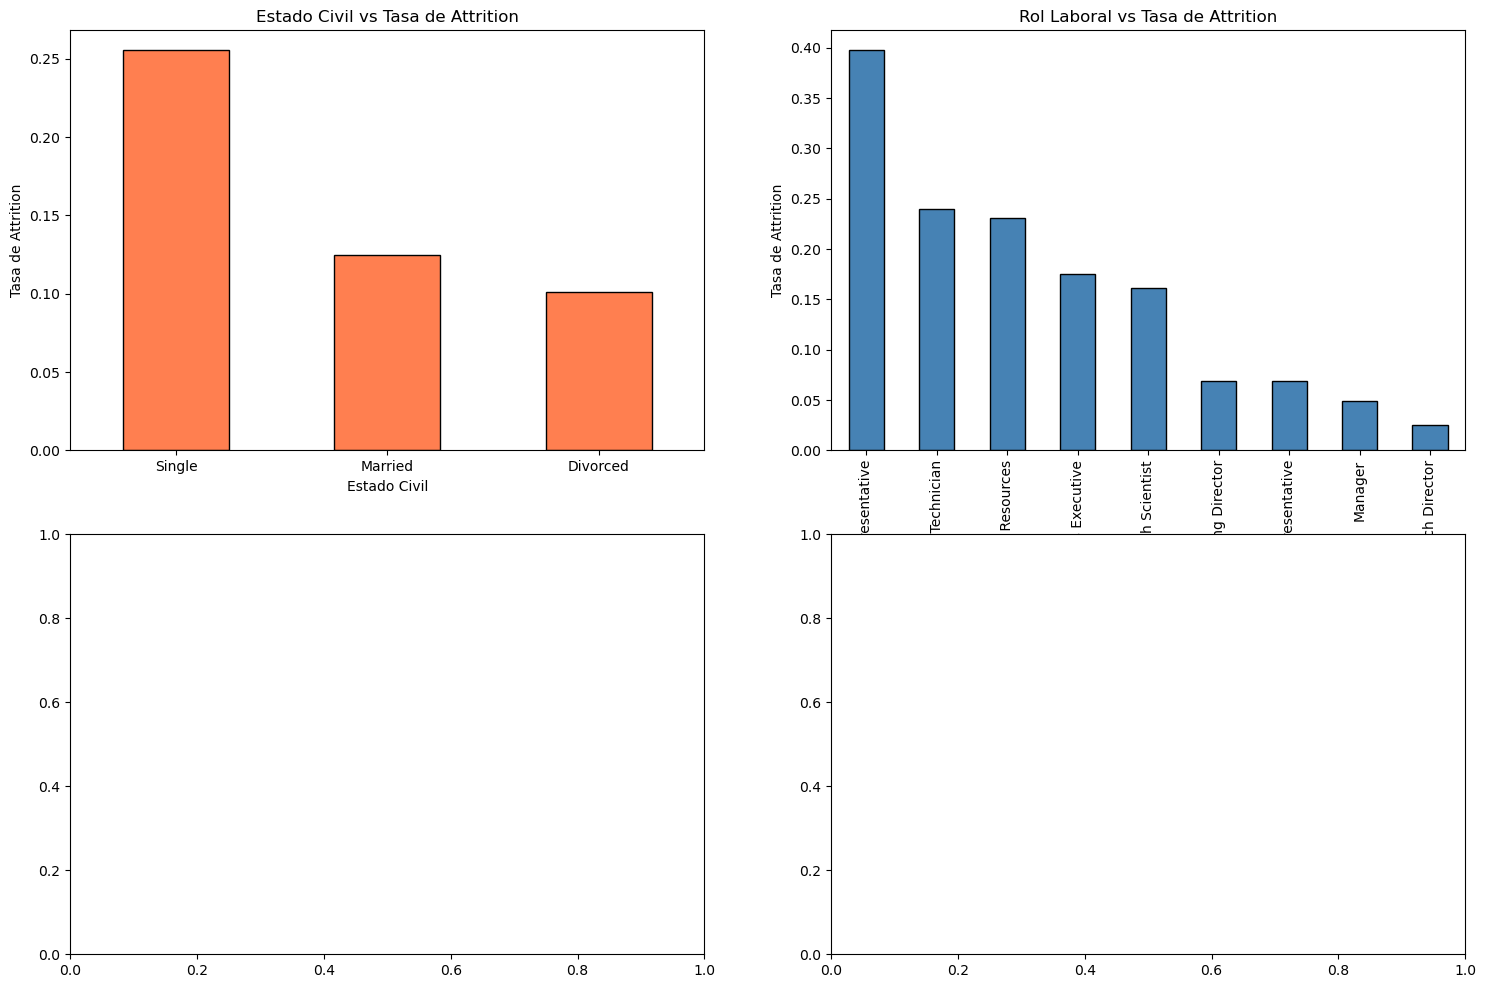

In [29]:


# Los empleados solteros tienden a irse en comparación con los casados ​​y divorciados
# Los representantes de ventas tienden a irse en comparación con cualquier otro trabajo
# Los empleados menos involucrados tienden a dejar la empresa
# Los menos experimentados (nivel laboral bajo) tienden a dejar la empresa

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Estado Civil vs Attrition
marital_attrition = df.groupby('MaritalStatus')['Attrition'].mean().sort_values(ascending=False)
marital_attrition.plot(kind='bar', ax=axes[0,0], color='coral', edgecolor='black')
axes[0,0].set_title('Estado Civil vs Tasa de Attrition')
axes[0,0].set_xlabel('Estado Civil')
axes[0,0].set_ylabel('Tasa de Attrition')
axes[0,0].tick_params(axis='x', rotation=0)

# 2) Job Role vs Attrition
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False)
role_attrition.plot(kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Rol Laboral vs Tasa de Attrition')
axes[0,1].set_xlabel('Job Role')
axes[0,1].set_ylabel('Tasa de Attrition')
axes[0,1].tick_params(axis='x', rotation=45, ha='right')

# 3) Job Involvement vs Attrition
involv_attrition = df.groupby('JobInvolvement')['Attrition'].mean()
involv_attrition.plot(kind='bar', ax=axes[1,0], color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Nivel de Involucramiento vs Tasa de Attrition')
axes[1,0].set_xlabel('Job Involvement (1=bajo, 4=alto)')
axes[1,0].set_ylabel('Tasa de Attrition')
axes[1,0].tick_params(axis='x', rotation=0)

# 4) Job Level vs Attrition
level_attrition = df.groupby('JobLevel')['Attrition'].mean()
level_attrition.plot(kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Nivel Laboral vs Tasa de Attrition')
axes[1,1].set_xlabel('Job Level (1=junior, 5=senior)')
axes[1,1].set_ylabel('Tasa de Attrition')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Factores que influyen en la Rotación de Personal', fontsize=16)
plt.tight_layout()
plt.show()

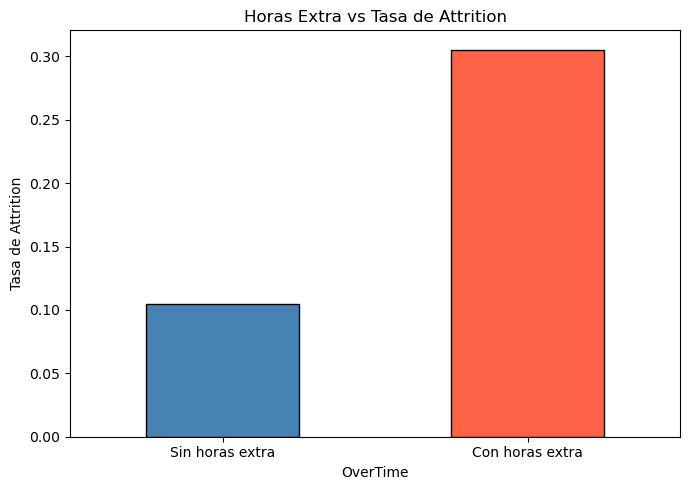

In [30]:
# Overtime vs Attrition
plt.figure(figsize=(7, 5))
overtime_attrition = df.groupby('OverTime')['Attrition'].mean()
overtime_attrition.index = ['Sin horas extra', 'Con horas extra']
overtime_attrition.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Horas Extra vs Tasa de Attrition')
plt.xlabel('OverTime')
plt.ylabel('Tasa de Attrition')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


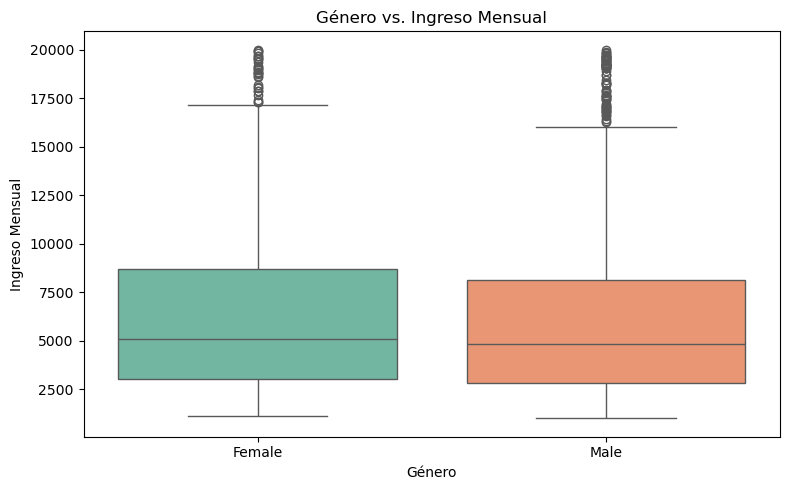

In [31]:
# Veamos el Gender vs. Monthly Income
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='MonthlyIncome', palette='Set2')
plt.title('Género vs. Ingreso Mensual')
plt.xlabel('Género')
plt.ylabel('Ingreso Mensual')
plt.tight_layout()
plt.show()

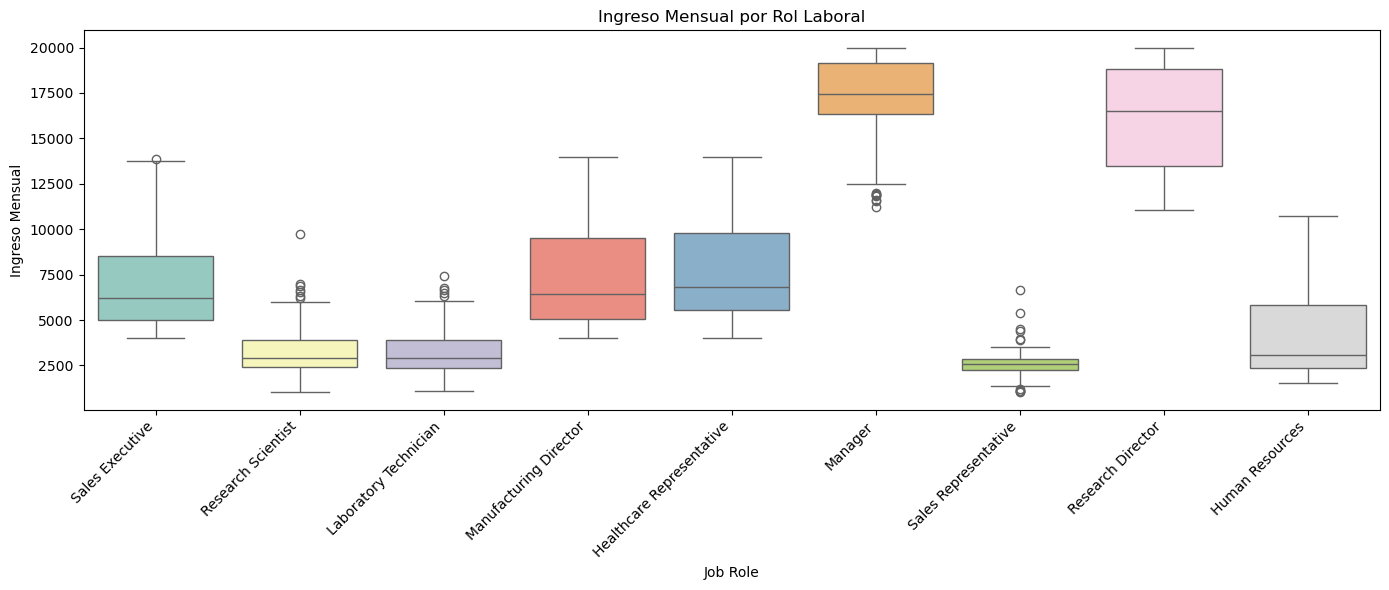

In [32]:
# Veamos el monthly income vs. job role
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome', palette='Set3')
plt.title('Ingreso Mensual por Rol Laboral')
plt.xlabel('Job Role')
plt.ylabel('Ingreso Mensual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# TAREA #4: CREAR LOS DATA SETS DE ENTRENAMIENTO Y TESTING Y LLEVAR A CABO LA LIMPIEZA DE DATOS

In [33]:
# Seleccionamos solo las columnas numéricas para el modelado
# Las columnas categóricas de texto se codifican con get_dummies
df_model = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                        'Gender', 'JobRole', 'MaritalStatus'])
print(f'Dimensiones tras One-Hot Encoding: {df_model.shape}')
df_model.head(3)

Dimensiones tras One-Hot Encoding: (1470, 51)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,False,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,False,True


In [34]:
# Definimos X (features) e y (target)
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nDistribución de la variable objetivo:')
print(y.value_counts())

X shape: (1470, 50)
y shape: (1470,)

Distribución de la variable objetivo:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [35]:
# Notemos que hemos eliminado la columna target, 'Attrition'
print('Columnas en X (features):')
print(X.columns.tolist())

Columnas en X (features):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRol

In [36]:
# División en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

X_train: (1176, 50) | y_train: (1176,)
X_test:  (294, 50)  | y_test:  (294,)


In [37]:
# Normalización con MinMaxScaler (escala 0-1)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado completado.')
print(f'Rango de valores X_train_scaled: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]')

Escalado completado.
Rango de valores X_train_scaled: [0.00, 1.00]


In [38]:
# Verificamos las dimensiones finales
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

X_train_scaled shape: (1176, 50)
X_test_scaled shape:  (294, 50)


# TAREA #5: ENTENDER LA TEORÍA DETRÁS DE LA REGRESIÓN LOGÍSTICA, REDES NEURONALES ALRTIFICIALES Y CLASIFICADORES DE BOSQUES ALEATORIOS

![alt text](https://drive.google.com/uc?id=1zC0o6mkPWhlIwbs1J2LXTVv1IjtTgBLw)

![alt text](https://drive.google.com/uc?id=1JahiZRxjM1gd1cdSlJXBsSmR3cCrZEwr)

![alt text](https://drive.google.com/uc?id=1Vf81FJgCX518kr8FFS-sgzT6Nu7yjMQA)

![alt text](https://drive.google.com/uc?id=11_L_2NlgtZJulG5BI6Lj8MMGpO5F_QJV)

![alt text](https://drive.google.com/uc?id=1azYXfWAiUl1LkzEJXYN-GRZneTfzMsVV)

# TAREA #6: ENTENDER COMO SE EVALUAN LOS MODELOS DE CLASIFICACIÓN

![alt text](https://drive.google.com/uc?id=1Mj1ZhIqcnJl1tfIHeq6R6T8LVzbodtqa)

![alt text](https://drive.google.com/uc?id=1095MBU9oYD1eE65fTrz-8sFgYbbvwAuH)

![alt text](https://drive.google.com/uc?id=1OojsDQecO-69GQFDYsULNhqgxAP9PrU3)

![alt text](https://drive.google.com/uc?id=1G1-il6xFMUuz3nd78kvwiP3mcuXqZM3U)

# TAREA #7: ENTRENAR Y EVALUAR UN CLASIFICADOR UTILIZANDO LA REGRESIÓN LOGÍSTICA

In [39]:
# Entrenamos el modelo de Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [40]:
# Predicciones en entrenamiento
y_pred_train_lr = log_reg.predict(X_train_scaled)
print('=== Resultados en el Conjunto de ENTRENAMIENTO ===')
print(f'Accuracy: {accuracy_score(y_train, y_pred_train_lr):.4f}')
print(classification_report(y_train, y_pred_train_lr, target_names=['No (0)', 'Sí (1)']))

=== Resultados en el Conjunto de ENTRENAMIENTO ===
Accuracy: 0.7832
              precision    recall  f1-score   support

      No (0)       0.96      0.78      0.86       986
      Sí (1)       0.41      0.82      0.55       190

    accuracy                           0.78      1176
   macro avg       0.68      0.80      0.70      1176
weighted avg       0.87      0.78      0.81      1176



In [41]:
# Resultados en el Conjunto de Testing
y_pred_test_lr = log_reg.predict(X_test_scaled)
print('=== Resultados en el Conjunto de TESTING ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test_lr):.4f}')
print(classification_report(y_test, y_pred_test_lr, target_names=['No (0)', 'Sí (1)']))

=== Resultados en el Conjunto de TESTING ===
Accuracy: 0.7721
              precision    recall  f1-score   support

      No (0)       0.92      0.79      0.85       247
      Sí (1)       0.38      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



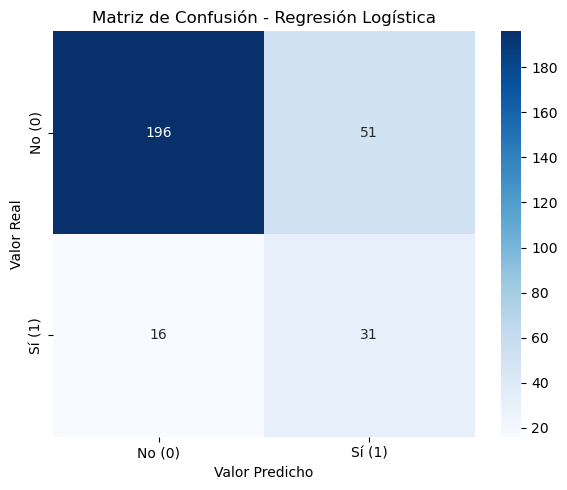

In [42]:
# Matriz de confusión - Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_test_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Sí (1)'],
            yticklabels=['No (0)', 'Sí (1)'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

In [ ]:
# Resultados en el Conjunto de Testing


# TAREA #8: ENTRENAR Y EVALUR UN CLASIFICADOR UTILIZANDO BOSQUES ALEATORIOS

In [43]:
# Entrenamos el modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                class_weight='balanced', max_depth=10)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [44]:
# Predicciones en entrenamiento
y_pred_train_rf = rf_model.predict(X_train_scaled)
print('=== Resultados en el Conjunto de ENTRENAMIENTO ===')
print(f'Accuracy: {accuracy_score(y_train, y_pred_train_rf):.4f}')
print(classification_report(y_train, y_pred_train_rf, target_names=['No (0)', 'Sí (1)']))

=== Resultados en el Conjunto de ENTRENAMIENTO ===
Accuracy: 0.9991
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00       986
      Sí (1)       1.00      0.99      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [45]:

# Resultados en el Conjunto de Testing
y_pred_test_rf = rf_model.predict(X_test_scaled)
print('=== Resultados en el Conjunto de TESTING ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test_rf):.4f}')
print(classification_report(y_test, y_pred_test_rf, target_names=['No (0)', 'Sí (1)']))

=== Resultados en el Conjunto de TESTING ===
Accuracy: 0.8299
              precision    recall  f1-score   support

      No (0)       0.85      0.97      0.91       247
      Sí (1)       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



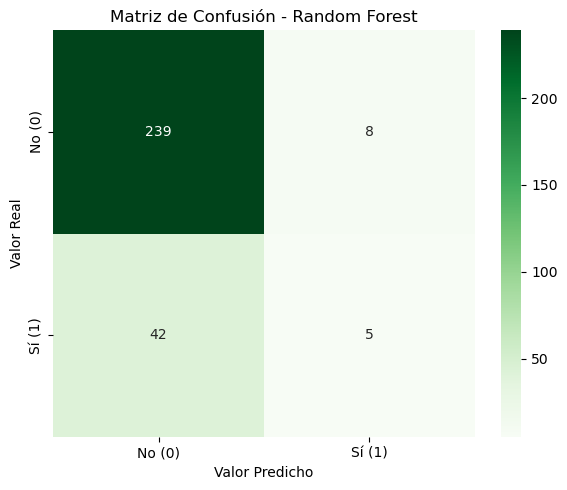

In [46]:
# Matriz de confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_test_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No (0)', 'Sí (1)'],
            yticklabels=['No (0)', 'Sí (1)'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

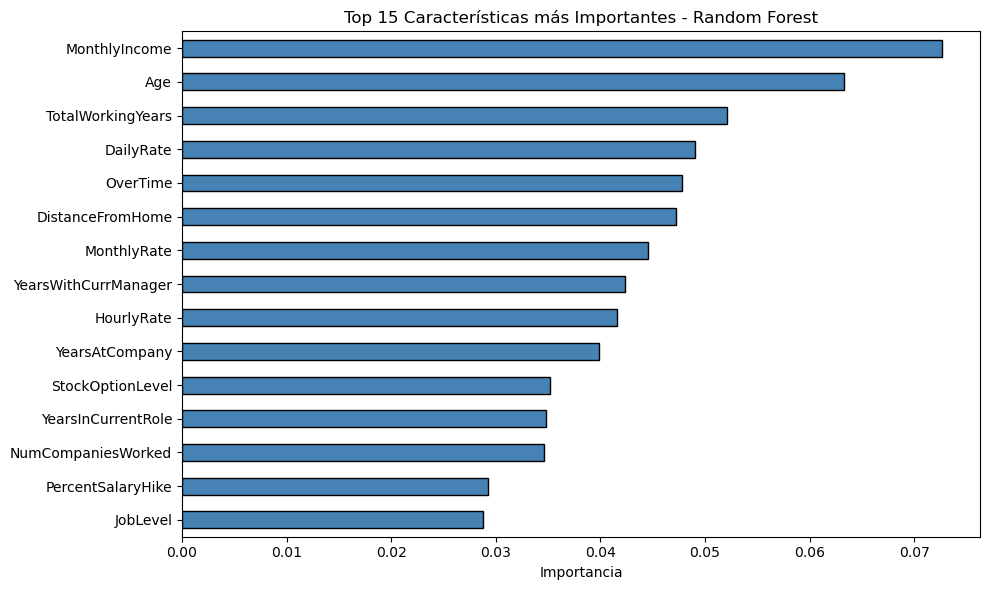

In [47]:
# Feature Importance - Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importance.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Características más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# TAREA #8: ENTRENAR Y EVALUR UN CLASIFICADOR UTILIZANDO DEEP LEARNING

In [48]:
# Definimos la arquitectura de la red neuronal
n_features = X_train_scaled.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')  # Salida binaria
])

model.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:

# Calculamos class weights para compensar el desbalanceo
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(f'Class weights: {class_weights}')

Class weights: {0: 0.5963488843813387, 1: 3.094736842105263}


In [50]:
# Entrenamiento de la red neuronal
epochs_hist = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=50,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5000 - loss: 0.6687 - val_accuracy: 0.6356 - val_loss: 0.6634
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7079 - loss: 0.6198 - val_accuracy: 0.6271 - val_loss: 0.6361
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7060 - loss: 0.5718 - val_accuracy: 0.7458 - val_loss: 0.5302
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7703 - loss: 0.5317 - val_accuracy: 0.6864 - val_loss: 0.5714
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7750 - loss: 0.5036 - val_accuracy: 0.8475 - val_loss: 0.4065
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.4824 - val_accuracy: 0.8559 - val_loss: 0.3753
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7977 - loss: 0.4865 - val_accuracy: 0.7712 - val_loss: 0.4796
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8299 - loss: 0.4537 - val_accuracy: 0.8220 - 

In [51]:
# Nota: Para usar SMOTE (oversampling) en su lugar:
# oversampler = SMOTE(random_state=0)
# smote_train, smote_target = oversampler.fit_resample(X_train, y_train)
# epochs_hist = model.fit(smote_train, smote_target, epochs=100, batch_size=50)

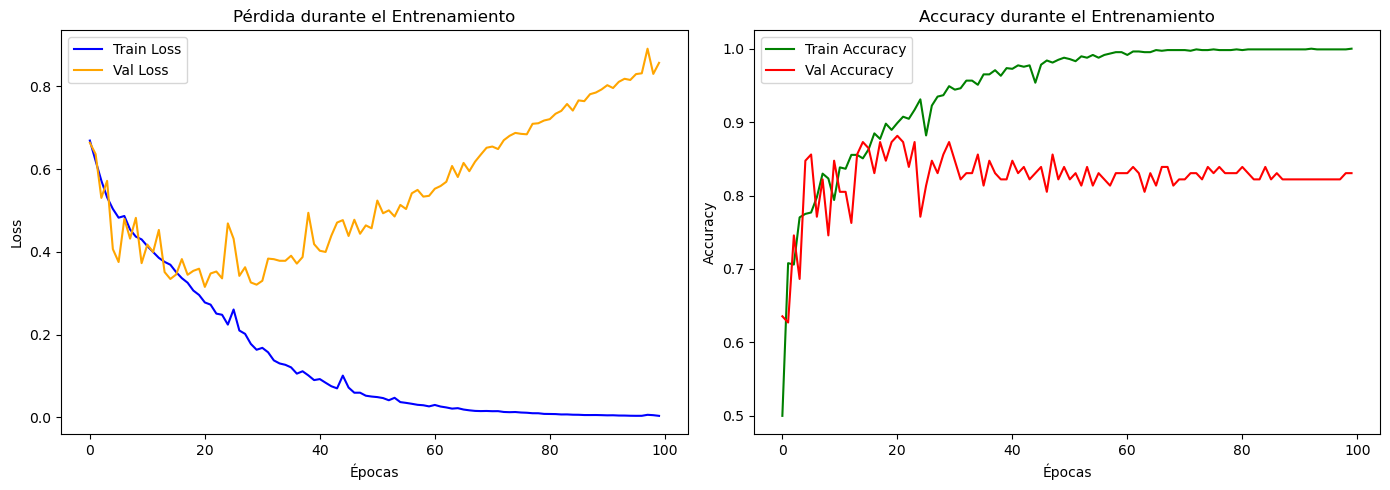

In [52]:

# Curvas de pérdida y accuracy durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_hist.history['loss'], label='Train Loss', color='blue')
axes[0].plot(epochs_hist.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Pérdida durante el Entrenamiento')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_hist.history['accuracy'], label='Train Accuracy', color='green')
axes[1].plot(epochs_hist.history['val_accuracy'], label='Val Accuracy', color='red')
axes[1].set_title('Accuracy durante el Entrenamiento')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
# Predicciones con umbral 0.5
y_pred_proba_dl = model.predict(X_test_scaled).flatten()
y_pred_test_dl  = (y_pred_proba_dl >= 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [54]:
# Resultados en el Conjunto de Testing - Deep Learning
print('=== Resultados en el Conjunto de TESTING - Deep Learning ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test_dl):.4f}')
print(classification_report(y_test, y_pred_test_dl, target_names=['No (0)', 'Sí (1)']))

=== Resultados en el Conjunto de TESTING - Deep Learning ===
Accuracy: 0.8231
              precision    recall  f1-score   support

      No (0)       0.88      0.92      0.90       247
      Sí (1)       0.43      0.32      0.37        47

    accuracy                           0.82       294
   macro avg       0.65      0.62      0.63       294
weighted avg       0.80      0.82      0.81       294



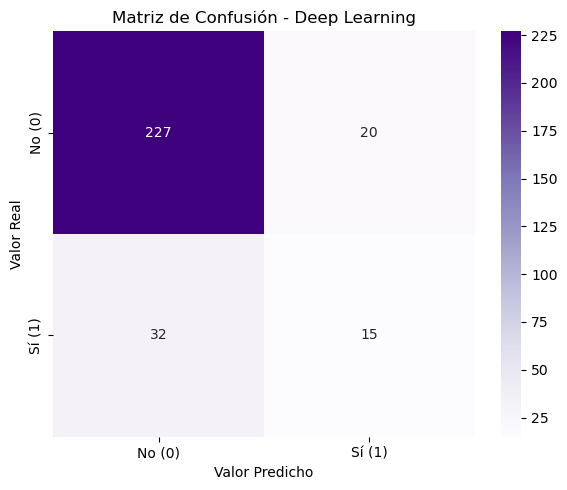

In [55]:
# Matriz de confusión - Deep Learning
cm_dl = confusion_matrix(y_test, y_pred_test_dl)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No (0)', 'Sí (1)'],
            yticklabels=['No (0)', 'Sí (1)'])
plt.title('Matriz de Confusión - Deep Learning')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

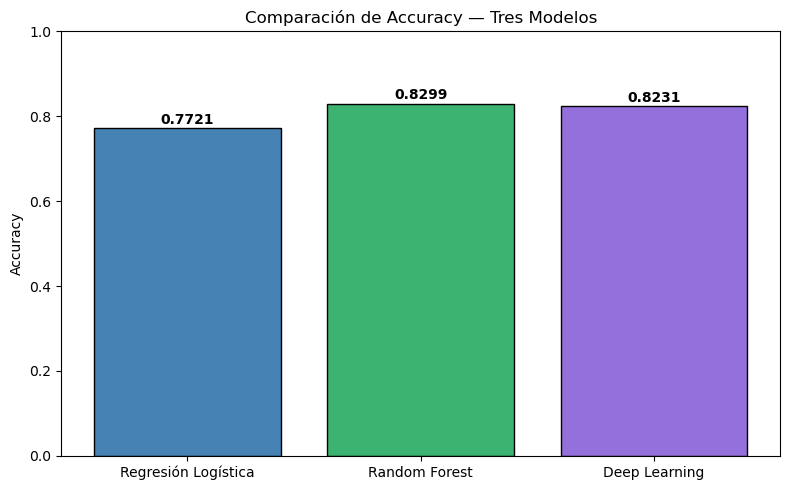

             Modelo Accuracy (Test)
Regresión Logística          0.7721
      Random Forest          0.8299
      Deep Learning          0.8231


In [56]:
# Comparación final de los tres modelos
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'Deep Learning'],
    'Accuracy (Test)': [
        accuracy_score(y_test, y_pred_test_lr),
        accuracy_score(y_test, y_pred_test_rf),
        accuracy_score(y_test, y_pred_test_dl)
    ]
})

resultados['Accuracy (Test)'] = resultados['Accuracy (Test)'].map('{:.4f}'.format)

plt.figure(figsize=(8, 5))
plt.bar(resultados['Modelo'], resultados['Accuracy (Test)'].astype(float),
        color=['steelblue', 'mediumseagreen', 'mediumpurple'], edgecolor='black')
plt.title('Comparación de Accuracy — Tres Modelos')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(resultados['Accuracy (Test)'].astype(float)):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(resultados.to_string(index=False))

# ¡EXCELENTE TRABAJO! USTED DEBE ESTAR ORGULLOSO DE SUS HABILIDADES RECIEN ADQUIRIDAS